In [340]:
# Import libraries :

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
# render figures directly in the notebook :
%matplotlib inline
# render higher resolution images :
%config InlineBackend.figure_format = 'retina'


# Seaborn is a Python data visualization library based on matplotlib :
import seaborn as sns 

# Missing data visualization module for Python :
import missingno as msno 
import datetime as dt


In [341]:
!pip install missingno

In [342]:
# Reading the dataset with pandas :
airbnb = pd.read_csv('airbnb.csv', index_col = 'Unnamed: 0')

In [343]:
# Displaying the 5 first and last rows of the dataset :
airbnb

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,"Manhattan, Harlem","(40.80379, -73.95257)",Entire home/apt,105$,4,2018-05-28,0.21,0,4.757555,4.8,0.639223,2017-11-22
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,"Manhattan, East Harlem","(40.79531, -73.9333)",Entire home/apt,125$,50,2018-05-06,0.66,188,4.344704,60.0,0.648778,2017-10-31
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,"Brooklyn, Clinton Hill","(40.68266, -73.96743000000002)",Entire home/apt,100$,45,2016-11-27,0.98,0,3.966214,54.0,0.631713,2016-05-24
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,"Brooklyn, Clinton Hill","(40.68832, -73.96366)",Entire home/apt,450$,2,2019-05-31,0.17,99,4.078581,2.4,0.703360,2018-11-25


In [344]:
# Reminder of the DataFrame :
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","(40.63222, -73.93398)",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","(40.78761, -73.96862)",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","(40.7007, -73.99517)",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","(40.79169, -73.97498)",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","(40.71884, -73.98354)",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23


In [345]:
# Removing "(" and ")" from coordinates : 
airbnb['coordinates'] = airbnb['coordinates'].str.replace("(","") # Deleting "(" 
airbnb['coordinates'] = airbnb['coordinates'].str.replace(")","") # Deleting ")" 

# Printing the header of the column :
airbnb['coordinates'].head()

0    40.63222, -73.93398
1    40.78761, -73.96862
2     40.7007, -73.99517
3    40.79169, -73.97498
4    40.71884, -73.98354
Name: coordinates, dtype: object

In [346]:
# Spliting coordinates column into two new columns : lat_long[0] and lat_long[1] 
lat_long = airbnb['coordinates'].str.split(",", expand = True)
lat_long.head()

,0,1
0,40.63222,-73.93398
1,40.78761,-73.96862
2,40.7007,-73.99517
3,40.79169,-73.97498
4,40.71884,-73.98354


In [347]:
# Assigning correct columns to latitude and longitude columns in airbnb
airbnb['latitude'] = lat_long[0]
airbnb['longitude'] = lat_long[1]
# Print the header and confirm new column creation
airbnb.head()

,listing_id,name,host_id,host_name,neighbourhood_full,coordinates,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,"Brooklyn, Flatlands","40.63222, -73.93398",Private room,45$,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,"Manhattan, Upper West Side","40.78761, -73.96862",Entire home/apt,135$,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,"Brooklyn, Brooklyn Heights","40.7007, -73.99517",Entire home/apt,150$,0,NaN,NaN,65,NaN,NaN,NaN,2018-08-15,40.7007,-73.99517
3,6425850,"Spacious, charming studio",32715865,Yelena,"Manhattan, Upper West Side","40.79169, -73.97498",Entire home/apt,86$,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,"Manhattan, Lower East Side","40.71884, -73.98354",Private room,160$,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354


In [348]:
# Droping coordinates column :
airbnb.drop('coordinates', axis = 1, inplace = True)

In [349]:
# Converting latitude and longitude to float :
airbnb['latitude'] = airbnb['latitude'].astype('float')
airbnb['longitude'] = airbnb['longitude'].astype('float')

# Print dtypes again :
airbnb.dtypes

listing_id              int64
name                   object
host_id                 int64
host_name              object
neighbourhood_full     object
room_type              object
price                  object
number_of_reviews       int64
last_review            object
reviews_per_month     float64
availability_365        int64
rating                float64
number_of_stays       float64
5_stars               float64
listing_added          object
latitude              float64
longitude             float64
dtype: object

> - Printing the info confirms our hunch about the following :
>     - There is missing data in the **`price`**, **`last_review`**, **`reviews_per_month`**, **`rating`**, **`number_of_stays`**, **`5_stars`** columns : **`problem 4`**
>     - The missingness of **`last_review`**, **`reviews_per_month`**, **`rating`**, **`number_of_stays`**, **`5_stars`** are related since they have the same amount of missing data. We will confirm later with **`missingno`** : **`problem 4`**

In [351]:
# Print info of DataFrame :
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10019 entries, 0 to 10018
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          10019 non-null  int64  
 1   name                10014 non-null  object 
 2   host_id             10019 non-null  int64  
 3   host_name           10017 non-null  object 
 4   neighbourhood_full  10019 non-null  object 
 5   room_type           10019 non-null  object 
 6   price               9781 non-null   object 
 7   number_of_reviews   10019 non-null  int64  
 8   last_review         7944 non-null   object 
 9   reviews_per_month   7944 non-null   float64
 10  availability_365    10019 non-null  int64  
 11  rating              7944 non-null   float64
 12  number_of_stays     7944 non-null   float64
 13  5_stars             7944 non-null   float64
 14  listing_added       10019 non-null  object 
 15  latitude            10019 non-null  float64
 16  longitude

In [352]:
# Print number of missing values :
airbnb.isna().sum()

listing_id               0
name                     5
host_id                  0
host_name                2
neighbourhood_full       0
room_type                0
price                  238
number_of_reviews        0
last_review           2075
reviews_per_month     2075
availability_365         0
rating                2075
number_of_stays       2075
5_stars               2075
listing_added            0
latitude                 0
longitude                0
dtype: int64

> There are a variety of ways of **dealing with missing data** that is dependent on type of missingness, as well as the business assumptions behind our data - our options could be :
> - **Dropping missing data** (if the data dropped does not impact or skew our data)
> - **Setting to missing and impute with statistical measures** (median, mean, mode ...)
> - **Impute based on business assumptions of our data**.

In [354]:
# Print description of DataFrame :
airbnb.describe()

,listing_id,host_id,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars,latitude,longitude
count,1.001900e+04,1.001900e+04,10019.000000,7944.000000,10019.000000,7944.000000,7944.000000,7944.000000,10019.000000,10019.000000
mean,1.927634e+07,6.795923e+07,22.459727,1.353894,112.284260,4.014458,33.991541,0.718599,40.729102,-73.951911
std,1.095056e+07,7.863106e+07,43.173896,1.615380,131.636043,0.575064,56.089279,0.079978,0.054636,0.045910
min,3.831000e+03,2.787000e+03,0.000000,0.010000,0.000000,3.000633,1.200000,0.600026,40.508680,-74.239860
25%,9.674772e+06,7.910880e+06,1.000000,0.200000,0.000000,3.520443,3.600000,0.655576,40.689880,-73.982845
50%,2.007030e+07,3.165167e+07,5.000000,0.710000,44.000000,4.027965,10.800000,0.709768,40.723010,-73.955430
75%,2.933864e+07,1.074344e+08,22.000000,2.000000,226.000000,4.516378,38.400000,0.763978,40.763390,-73.936065
max,3.648724e+07,2.741034e+08,510.000000,16.220000,365.000000,5.181114,612.000000,0.950339,40.913060,-73.719280


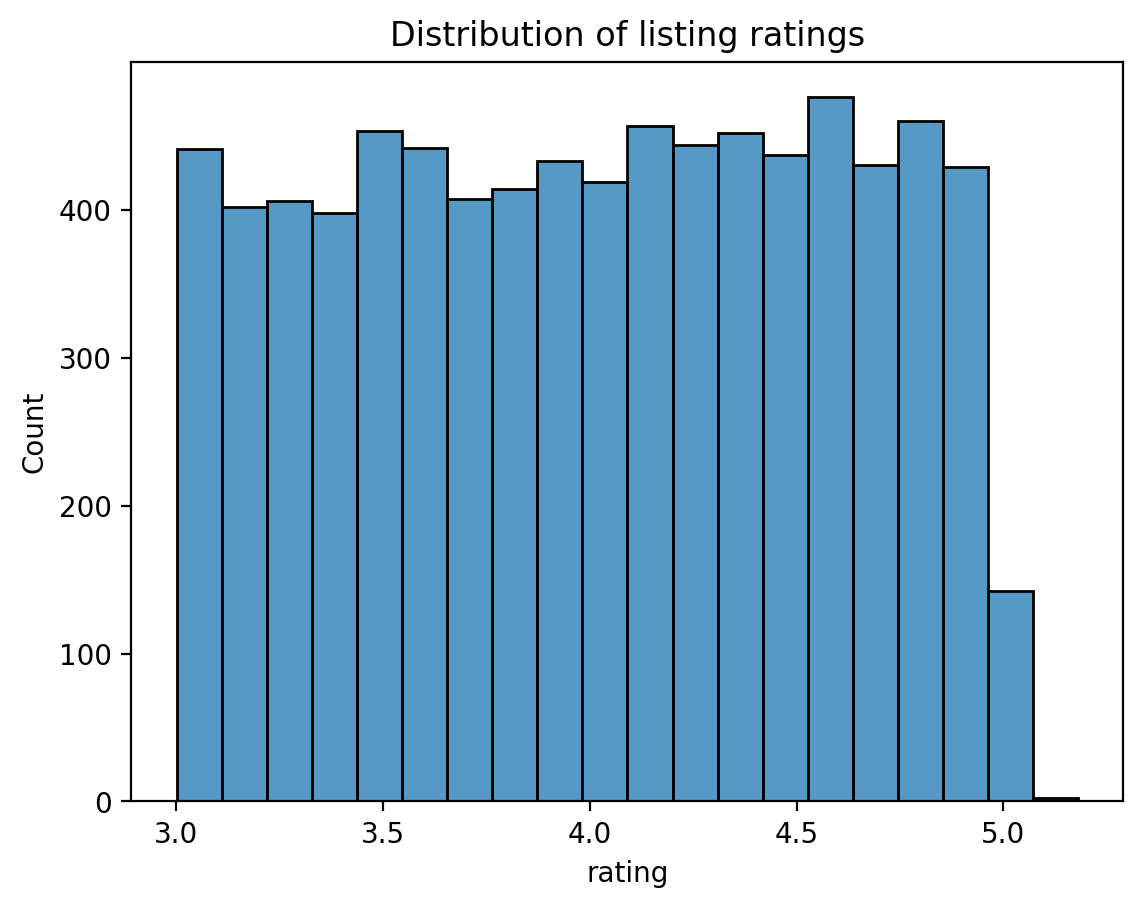

In [355]:
# Visualize the distribution of the rating column :
sns.histplot(airbnb['rating'], bins = 20)
plt.title('Distribution of listing ratings')
plt.show()

In [356]:
# Isolating rows of rating > 5.0
airbnb[airbnb['rating'] > 5.0]

,listing_id,name,host_id,host_name,neighbourhood_full,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
1925,36411407,Brand new 1 bedroom steps from Soho!,33917435,Mike,"Manhattan, Lower East Side",Entire home/apt,150$,1,2019-07-06,1.0,13,5.017040,1.2,0.870161,2018-12-31,40.71825,-73.99019
6732,36390226,Comfortable clean Bedstuy private room,267932490,Angela,"Brooklyn, Bedford-Stuyvesant",Private room,45$,2,2019-07-08,2.0,14,5.087091,2.4,0.950339,2019-01-02,40.69551,-73.93951
8821,36413632,Spacious 2BR in Beautiful Brooklyn Heights,6608220,Matt,"Brooklyn, Brooklyn Heights",Entire home/apt,550$,1,2019-07-07,1.0,230,5.181114,1.2,0.805418,2019-01-01,40.69827,-73.99649


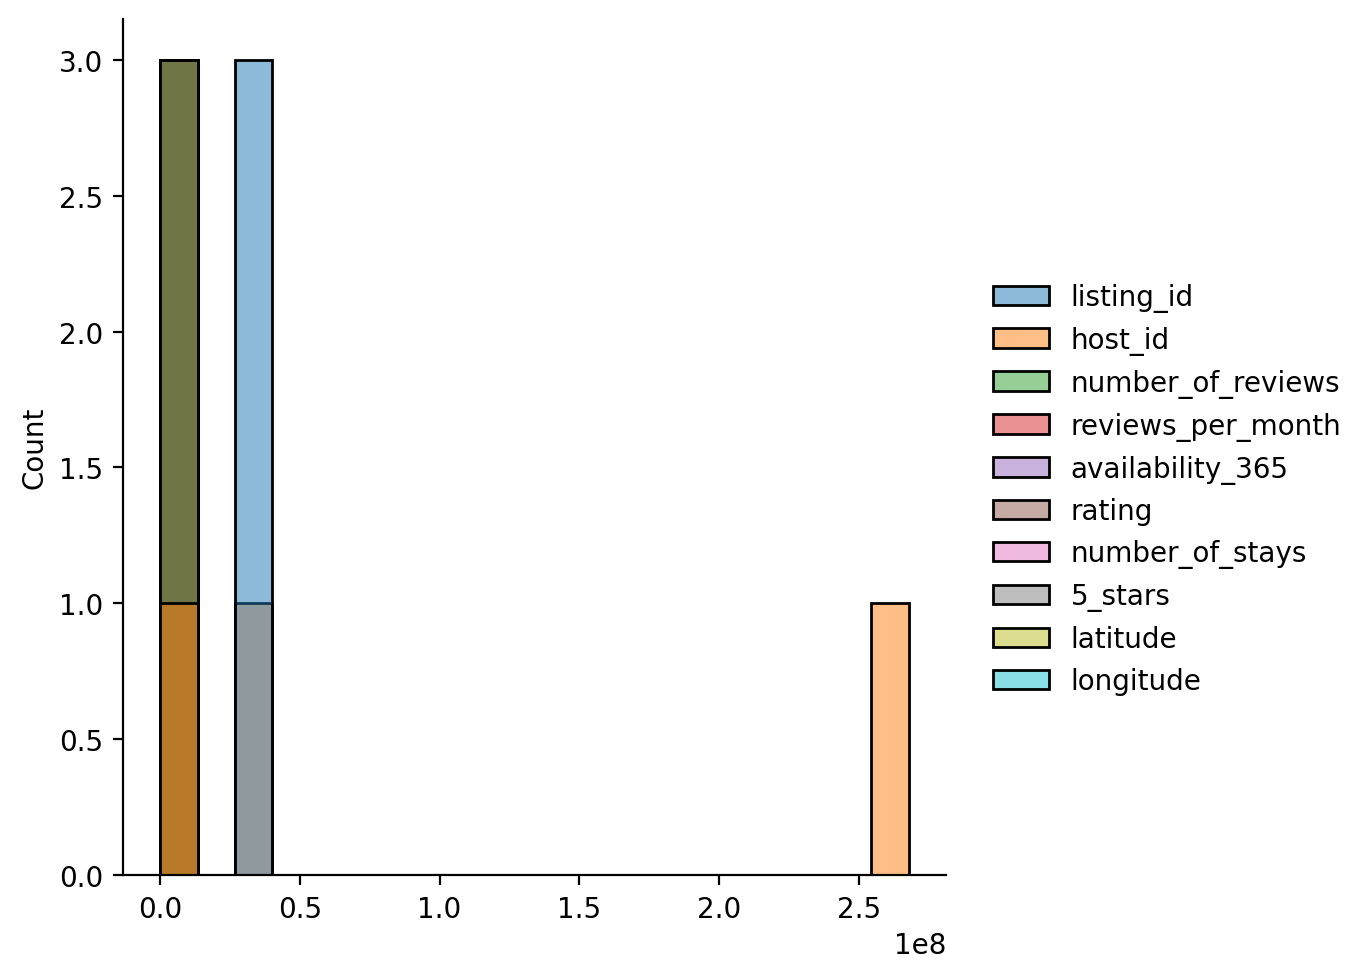

In [357]:
# Visualization of the elements of the rating column that have a value greater than 5 :
sns.displot(airbnb[airbnb['rating'] > 5.0], bins = 20)
plt.show()

In [358]:
# Droping these rows and make sure we have effected changes :
airbnb.drop(airbnb[airbnb['rating'] > 5.0].index, inplace = True)

# Making sure the rows had been deleted
airbnb[airbnb['rating'] > 5.0].info

<bound method DataFrame.info of Empty DataFrame
Columns: [listing_id, name, host_id, host_name, neighbourhood_full, room_type, price, number_of_reviews, last_review, reviews_per_month, availability_365, rating, number_of_stays, 5_stars, listing_added, latitude, longitude]
Index: []>

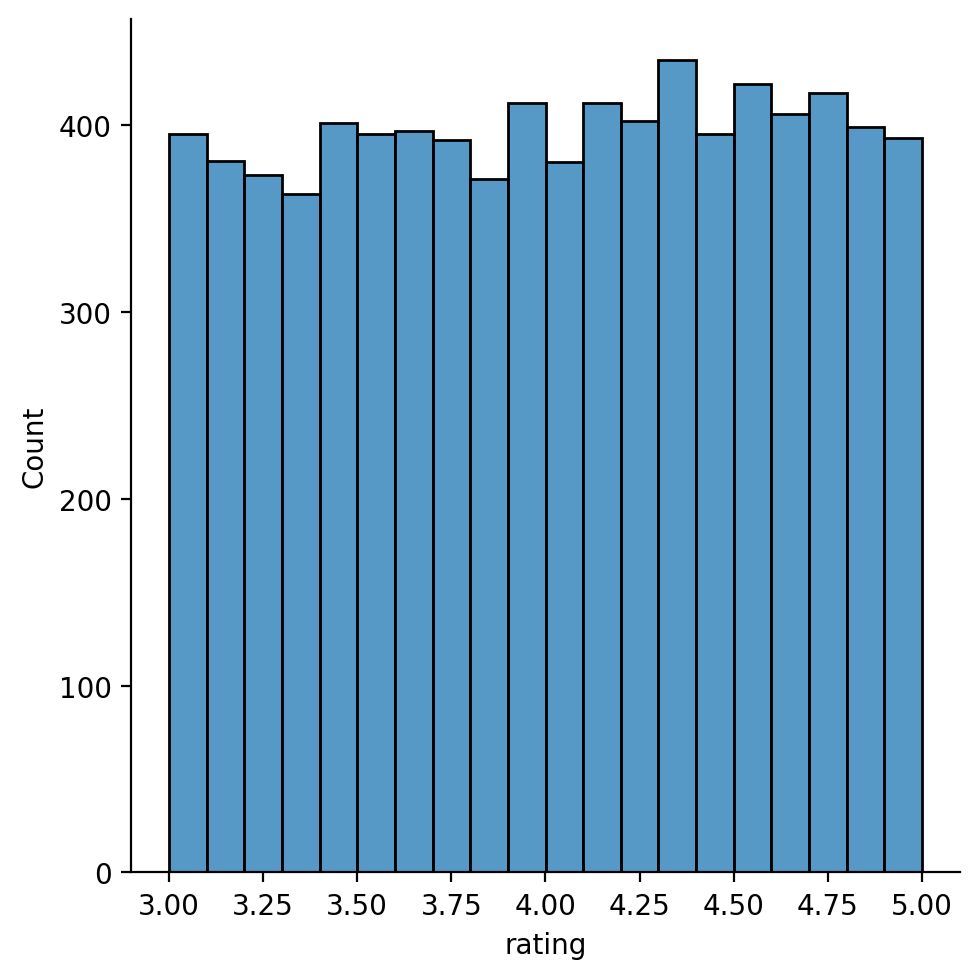

In [359]:
# Visualize the rating column again :
sns.displot(airbnb['rating'], bins = 20)
plt.show()

In [360]:
# Getting the maximum :
airbnb['rating'].max()

4.999561104773598

In [361]:
# Find number of unique values in room_type column :
airbnb['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Private', 'Shared room',
       'PRIVATE ROOM', 'home', '   Shared room      '], dtype=object)

In [362]:
# Dealing with capitalized values :
airbnb['room_type'] = airbnb['room_type'].str.lower()
airbnb['room_type'].unique()

array(['private room', 'entire home/apt', 'private', 'shared room',
       'home', '   shared room      '], dtype=object)

In [363]:
# Dealing with trailing spaces :
airbnb['room_type'] = airbnb['room_type'].str.strip()
airbnb['room_type'].unique()

array(['private room', 'entire home/apt', 'private', 'shared room',
       'home'], dtype=object)

In [364]:
# Replacing values to 'Shared room', 'Entire place', 'Private room' and 'Hotel room' (if applicable).
mappings = {'private room': 'Private Room', 
            'private': 'Private Room',
            'entire home/apt': 'Entire place',
            'shared room': 'Shared room',
            'home': 'Entire place'}

# Replacing values and collapsing data :
airbnb['room_type'] = airbnb['room_type'].replace(mappings)
airbnb['room_type'].unique()

array(['Private Room', 'Entire place', 'Shared room'], dtype=object)

In [365]:
# How many values of different room_types do we have?
airbnb['room_type'].value_counts()

room_type
Entire place    5184
Private Room    4606
Shared room      226
Name: count, dtype: int64

In [366]:
# Remove $ from price before conversion to float
airbnb['price'] = airbnb['price'].str.strip("$")
# Print header to make sure change was done
airbnb['price'].head()

0     45
1    135
2    150
3     86
4    160
Name: price, dtype: object

In [367]:
# Convert price to float
airbnb['price'] = airbnb['price'].astype('float')
# Calculate mean of price after conversion
airbnb['price'].mean()

150.87523010840664

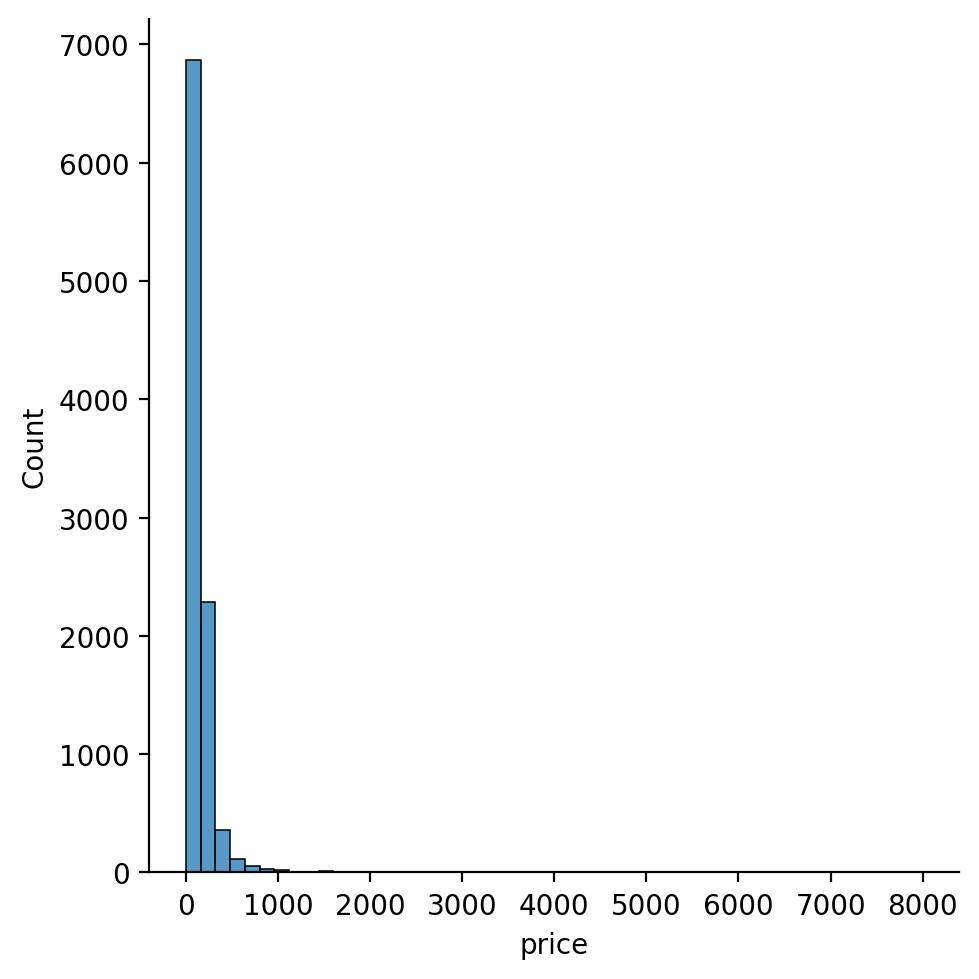

In [368]:
# Visualize distribution of prices
sns.displot(airbnb['price'], bins = 50)
plt.show()

In [369]:
# Printing header of two columns :
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaN
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [370]:
# Converting both columns to datetime :
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'], format = '%Y-%m-%d')
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'], format = '%Y-%m-%d')

In [371]:
# Printing header of two columns :
airbnb[['listing_added', 'last_review']].head()

,listing_added,last_review
0,2018-06-08,2018-12-12
1,2018-12-25,2019-06-30
2,2018-08-15,NaT
3,2017-03-20,2017-09-23
4,2020-10-23,2019-06-12


In [372]:
# Printing datatypes of both columns :
airbnb[['listing_added', 'last_review']].dtypes

listing_added    datetime64[ns]
last_review      datetime64[ns]
dtype: object

In [373]:
# Printing header of column :
airbnb['neighbourhood_full'].head()

0           Brooklyn, Flatlands
1    Manhattan, Upper West Side
2    Brooklyn, Brooklyn Heights
3    Manhattan, Upper West Side
4    Manhattan, Lower East Side
Name: neighbourhood_full, dtype: object

In [374]:
# Spliting neighbourhood_full :
borough_neighbourhood = airbnb['neighbourhood_full'].str.split(",", expand = True)
borough_neighbourhood.head()

,0,1
0,Brooklyn,Flatlands
1,Manhattan,Upper West Side
2,Brooklyn,Brooklyn Heights
3,Manhattan,Upper West Side
4,Manhattan,Lower East Side


In [375]:
# Creating borough and neighbourhood columns :
airbnb['borough'] = borough_neighbourhood[0]
airbnb['neighbourhood'] = borough_neighbourhood[1]

# Printing header of the recently created columns :
airbnb[['neighbourhood_full', 'borough', 'neighbourhood']].head()

,neighbourhood_full,borough,neighbourhood
0,"Brooklyn, Flatlands",Brooklyn,Flatlands
1,"Manhattan, Upper West Side",Manhattan,Upper West Side
2,"Brooklyn, Brooklyn Heights",Brooklyn,Brooklyn Heights
3,"Manhattan, Upper West Side",Manhattan,Upper West Side
4,"Manhattan, Lower East Side",Manhattan,Lower East Side


In [376]:
# Droping the neighbourhood_full column :
airbnb.drop('neighbourhood_full', axis = 1, inplace = True)

In [377]:
# Printing out unique values of borough :
airbnb['borough'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island'],
      dtype=object)

In [378]:
# Printing out unique values of neighbourhood :
airbnb['neighbourhood'].unique()

array([' Flatlands', ' Upper West Side', ' Brooklyn Heights',
       ' Lower East Side', ' Greenwich Village', ' Harlem',
       ' Sheepshead Bay', ' Theater District', ' Bushwick', ' Laurelton',
       ' Mott Haven', ' Flushing', ' Crown Heights', ' Midtown',
       ' Financial District', ' East Village', ' Park Slope',
       ' Washington Heights', ' Williamsburg', ' Chelsea',
       ' Bedford-Stuyvesant', ' Gowanus', ' Upper East Side',
       ' Ditmars Steinway', ' Cypress Hills', " Hell's Kitchen",
       ' Ridgewood', ' Marble Hill', ' Kips Bay', ' Prospect Heights',
       ' East New York', ' Concord', ' Stapleton', ' Astoria',
       ' East Harlem', ' Sunnyside', ' Gramercy',
       ' Prospect-Lefferts Gardens', ' Sunset Park', ' Forest Hills',
       ' Windsor Terrace', ' Clinton Hill', ' Murray Hill',
       ' Flatiron District', ' Greenpoint', ' East Flatbush', ' Tribeca',
       ' Woodhaven', ' Fort Greene', ' Inwood', ' Chinatown',
       ' Rockaway Beach', ' Woodside', ' 

In [379]:
# Striping white space from neighbourhood column :
airbnb['neighbourhood'] = airbnb['neighbourhood'].str.strip()

# Printing unique values again :
airbnb['neighbourhood'].unique()

array(['Flatlands', 'Upper West Side', 'Brooklyn Heights',
       'Lower East Side', 'Greenwich Village', 'Harlem', 'Sheepshead Bay',
       'Theater District', 'Bushwick', 'Laurelton', 'Mott Haven',
       'Flushing', 'Crown Heights', 'Midtown', 'Financial District',
       'East Village', 'Park Slope', 'Washington Heights', 'Williamsburg',
       'Chelsea', 'Bedford-Stuyvesant', 'Gowanus', 'Upper East Side',
       'Ditmars Steinway', 'Cypress Hills', "Hell's Kitchen", 'Ridgewood',
       'Marble Hill', 'Kips Bay', 'Prospect Heights', 'East New York',
       'Concord', 'Stapleton', 'Astoria', 'East Harlem', 'Sunnyside',
       'Gramercy', 'Prospect-Lefferts Gardens', 'Sunset Park',
       'Forest Hills', 'Windsor Terrace', 'Clinton Hill', 'Murray Hill',
       'Flatiron District', 'Greenpoint', 'East Flatbush', 'Tribeca',
       'Woodhaven', 'Fort Greene', 'Inwood', 'Chinatown',
       'Rockaway Beach', 'Woodside', 'Bayside', 'Bensonhurst', 'SoHo',
       'Red Hook', 'West Village', 

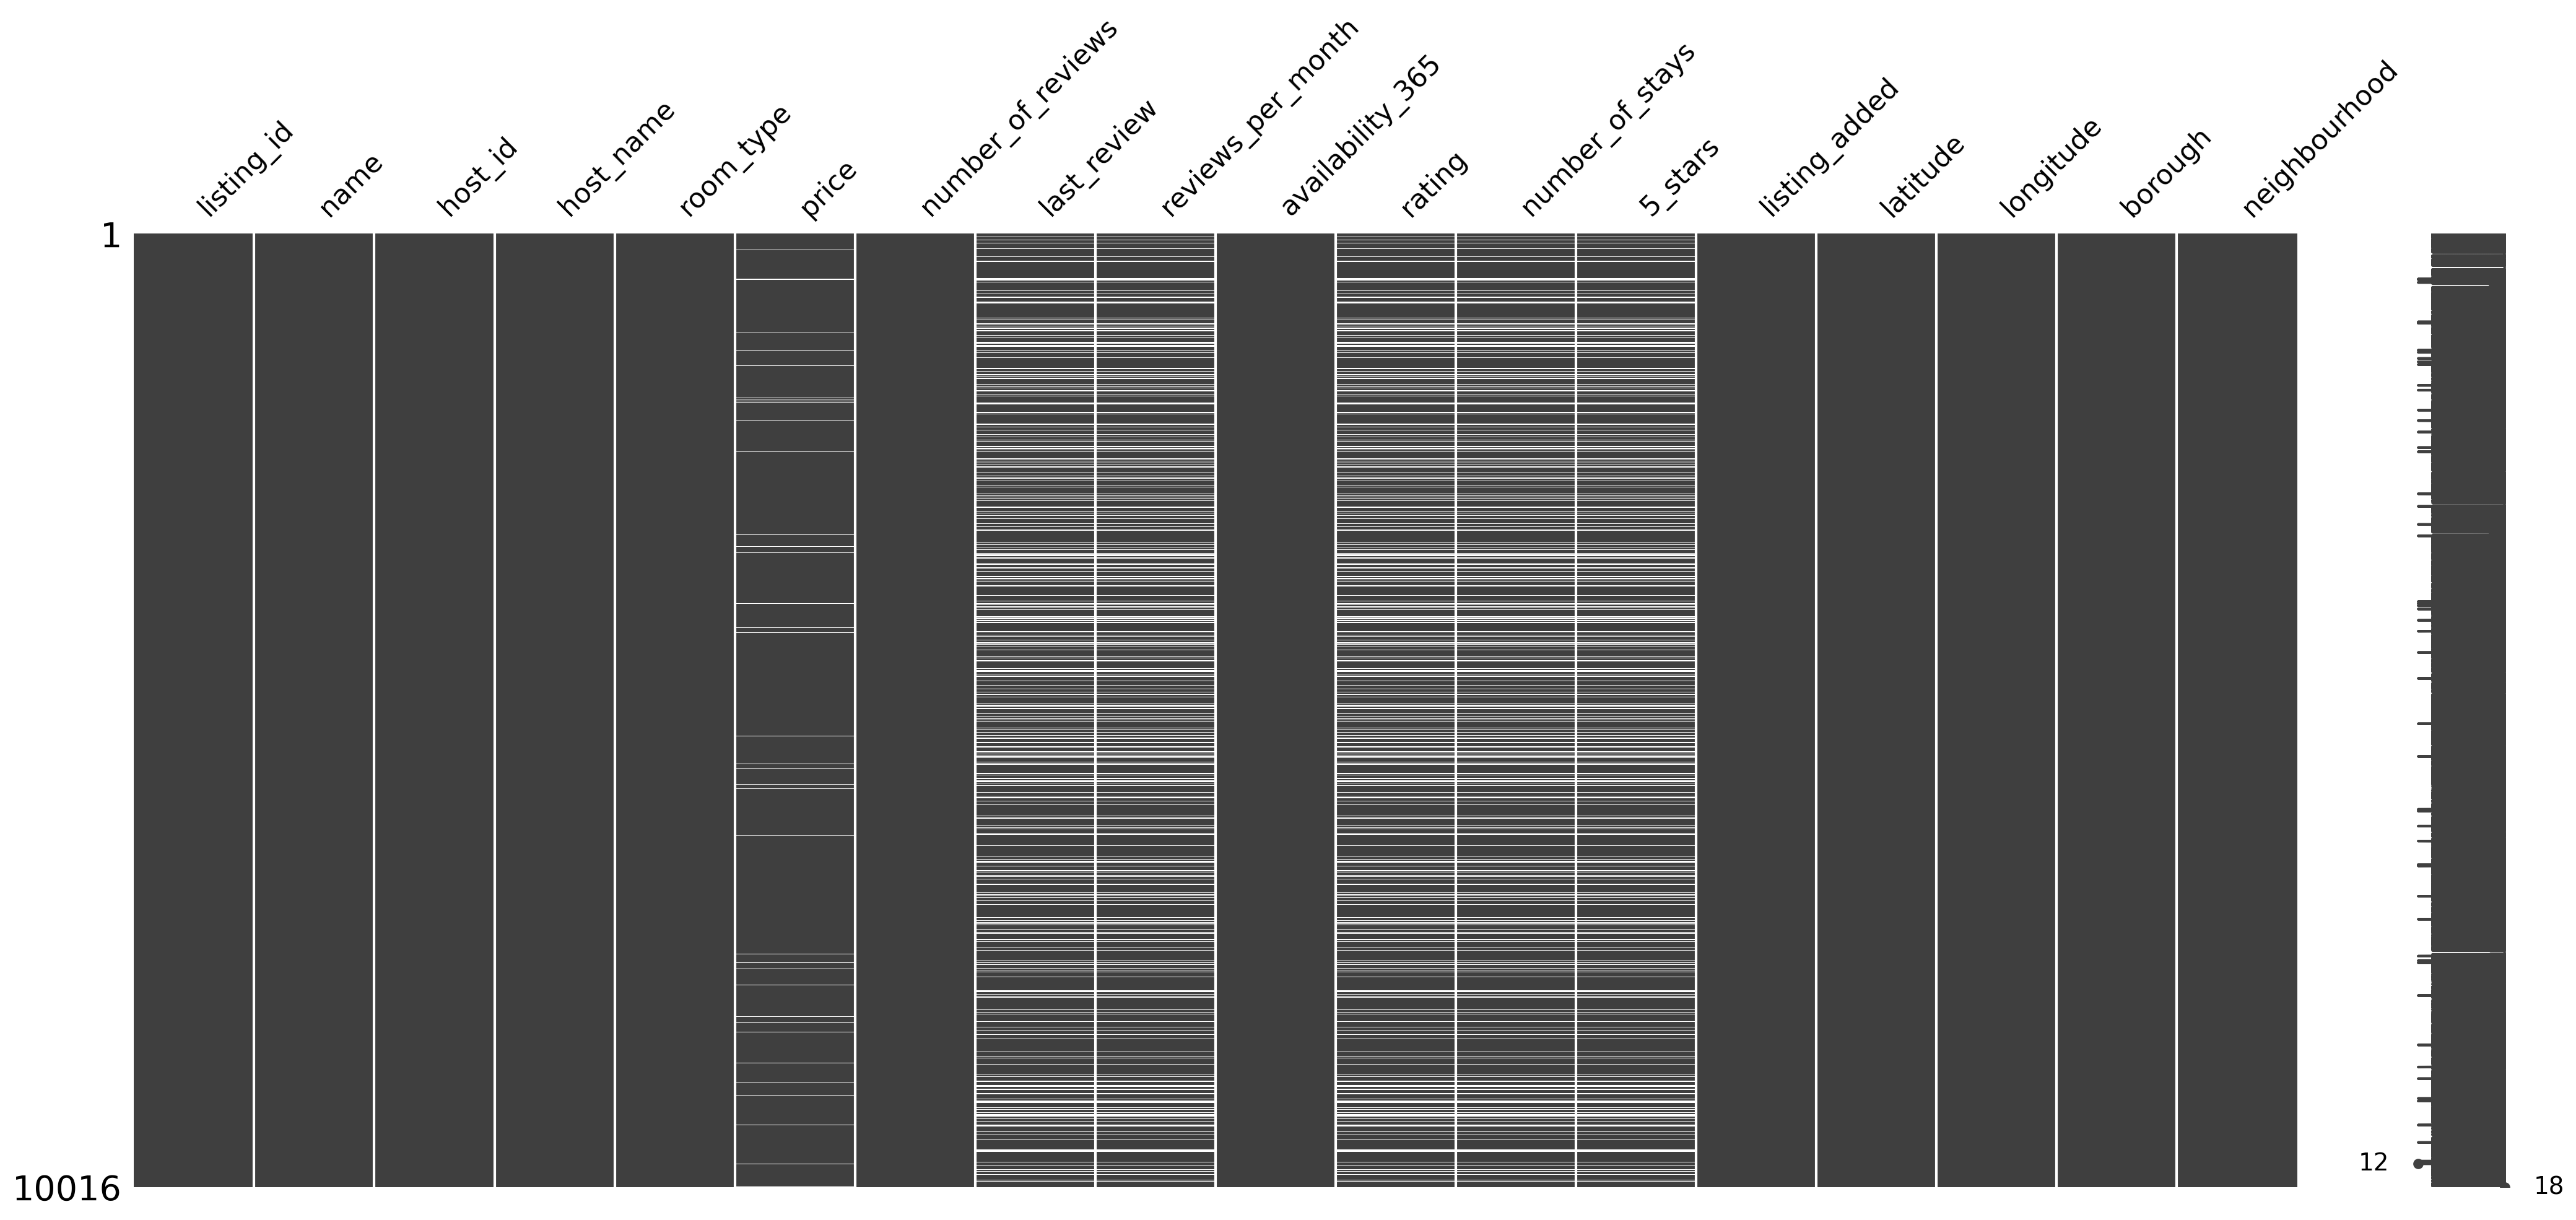

In [380]:
# Visualizing the missingness :
msno.matrix(airbnb)
plt.show()

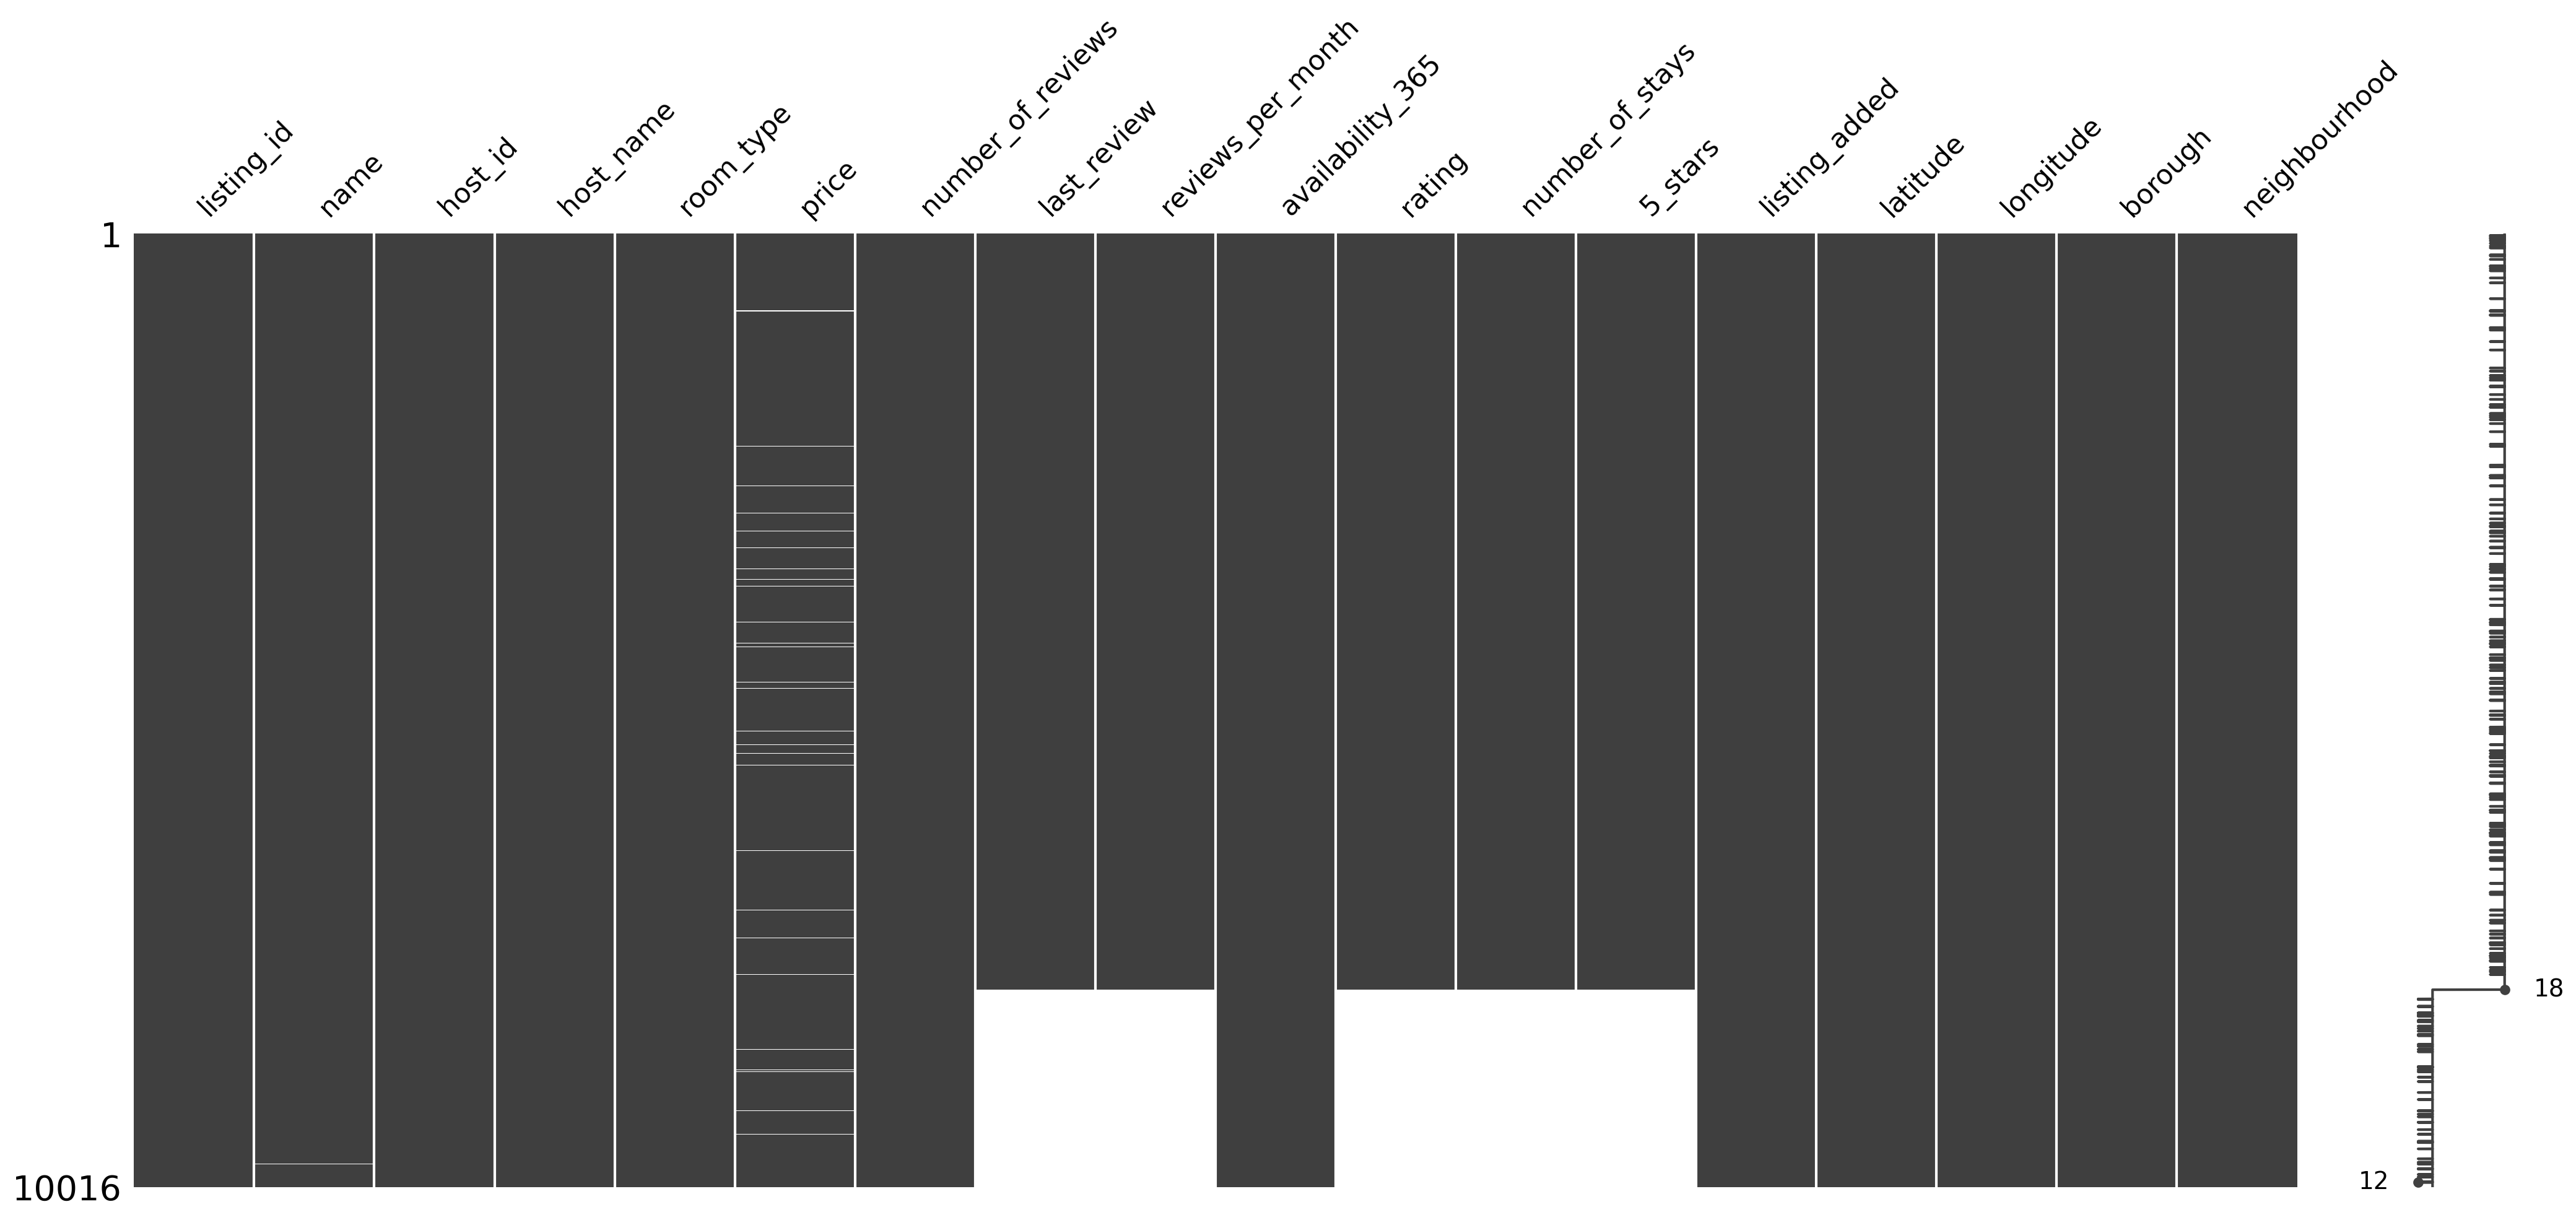

In [381]:
# Visualizing the missingness on sorted values :
msno.matrix(airbnb.sort_values(by = 'rating'))
plt.show()

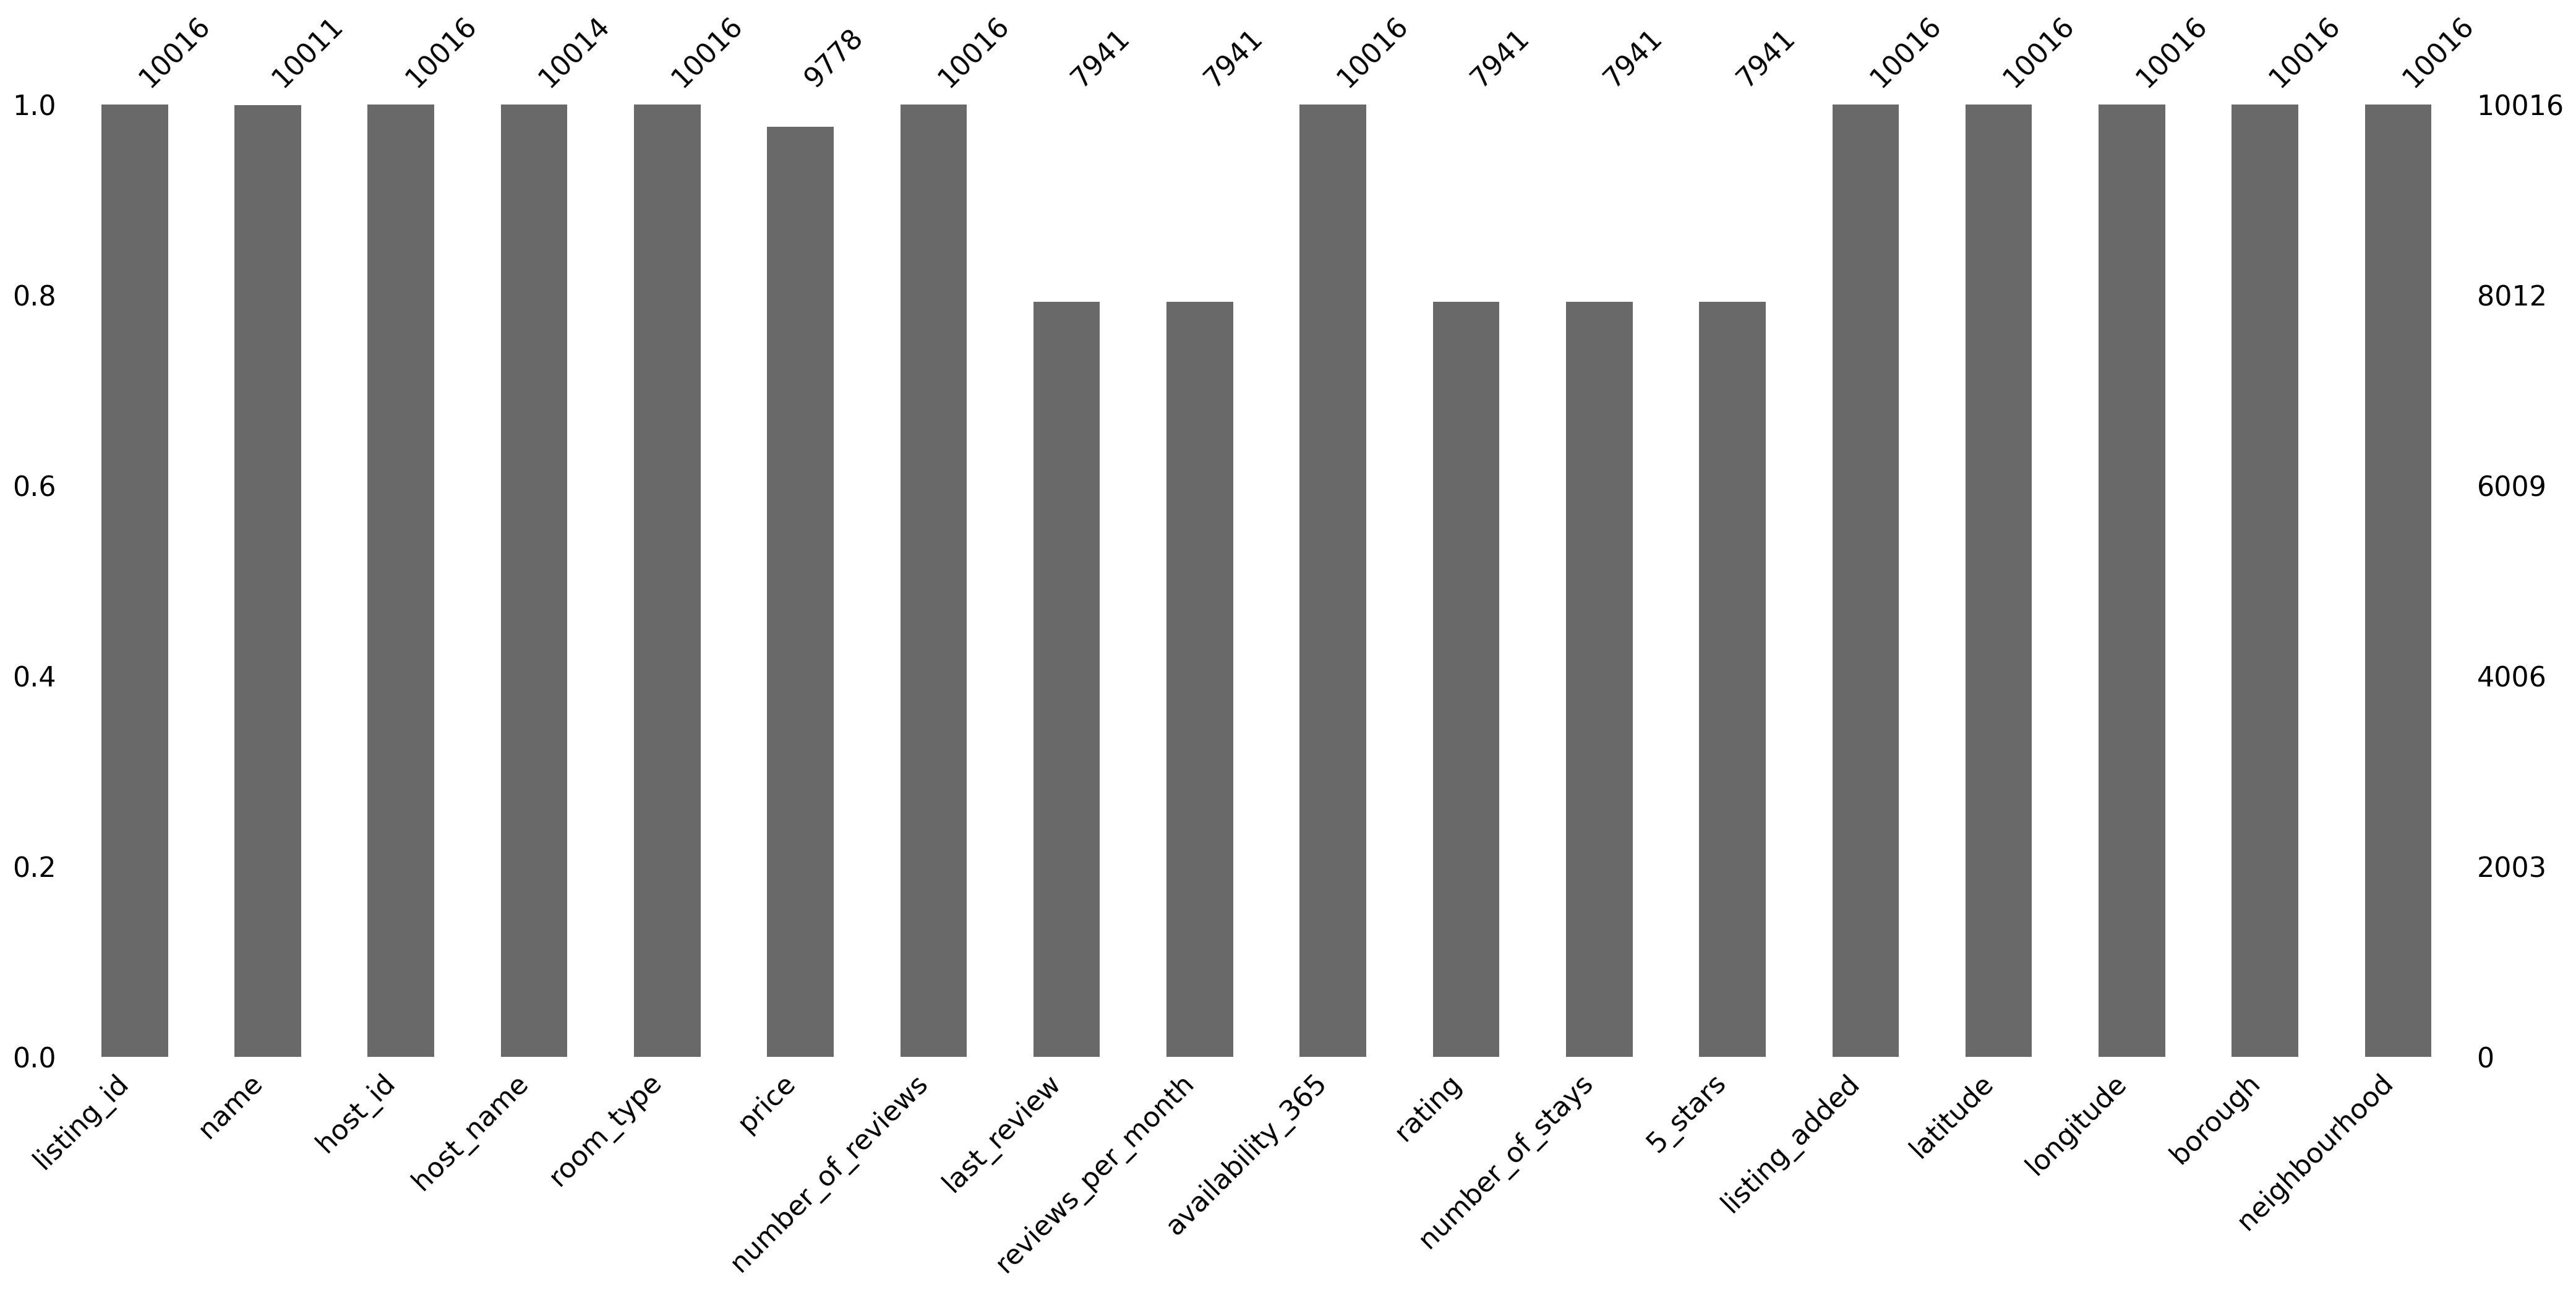

In [382]:
# Missingness barplot :
msno.bar(airbnb)
plt.show()

In [383]:
# Understanding DataFrame with missing values in rating, number_of_stays, 5_stars, reviews_per_month :
airbnb[airbnb['rating'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,2.075000e+03,2.075000e+03,2028.000000,2075.0,0,0.0,2075.000000,0.0,0.0,0.0,2075,2075.000000,2075.000000
mean,2.274238e+07,8.022455e+07,191.553748,0.0,NaT,NaN,104.531566,NaN,NaN,NaN,2018-06-08 17:01:31.951807232,40.732074,-73.956771
min,6.358800e+04,1.475100e+04,0.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-02-03 00:00:00,40.527000,-74.209410
25%,1.232923e+07,1.224305e+07,70.000000,0.0,NaT,NaN,0.000000,NaN,NaN,NaN,2018-04-05 00:00:00,40.697845,-73.985185
50%,2.345182e+07,4.040116e+07,120.000000,0.0,NaT,NaN,7.000000,NaN,NaN,NaN,2018-06-05 00:00:00,40.727790,-73.960940
75%,3.400364e+07,1.333498e+08,205.250000,0.0,NaT,NaN,211.000000,NaN,NaN,NaN,2018-08-13 00:00:00,40.763480,-73.939540
max,3.648724e+07,2.741034e+08,5250.000000,0.0,NaT,NaN,365.000000,NaN,NaN,NaN,2018-10-17 00:00:00,40.911690,-73.727310
std,1.123730e+07,8.663163e+07,316.186639,0.0,NaN,NaN,138.266525,NaN,NaN,NaN,NaN,0.051168,0.041065


In [384]:
# Understanding DataFrame with no missing values in rating, number_of_stays, 5_stars, reviews_per_month :
airbnb[~airbnb['rating'].isna()].describe() 

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude
count,7.941000e+03,7.941000e+03,7750.000000,7941.000000,7941,7941.000000,7941.000000,7941.000000,7941.000000,7941.000000,7941,7941.000000,7941.000000
mean,1.836419e+07,6.474110e+07,140.230581,28.336482,2018-10-07 01:01:39.282206208,1.353901,114.320111,4.014050,34.003778,0.718540,2018-04-03 13:28:02.357385728,40.728335,-73.950632
min,3.831000e+03,2.787000e+03,0.000000,1.000000,2011-03-28 00:00:00,0.010000,0.000000,3.000633,1.200000,0.600026,2010-09-22 00:00:00,40.508680,-74.239860
25%,8.964308e+06,7.138163e+06,69.000000,3.000000,2018-07-16 00:00:00,0.200000,0.000000,3.519751,3.600000,0.655573,2018-01-10 00:00:00,40.688560,-73.982130
50%,1.927436e+07,2.947846e+07,105.000000,9.000000,2019-05-19 00:00:00,0.700000,54.000000,4.027415,10.800000,0.709747,2018-11-13 00:00:00,40.721820,-73.954410
75%,2.787660e+07,1.016578e+08,170.000000,32.000000,2019-06-23 00:00:00,2.000000,229.000000,4.515626,38.400000,0.763948,2018-12-18 00:00:00,40.763390,-73.934930
max,3.635113e+07,2.733615e+08,8000.000000,510.000000,2019-07-08 00:00:00,16.220000,365.000000,4.999561,612.000000,0.939950,2020-10-23 00:00:00,40.913060,-73.719280
std,1.068788e+07,7.606089e+07,163.630337,46.746949,NaN,1.615659,129.789313,0.574787,56.096338,0.079927,NaN,0.055491,0.047017


In [385]:
# Imputing missing data :
airbnb = airbnb.fillna({'reviews_per_month':0,
                        'number_of_stays':0,
                        '5_stars':0})

In [386]:
# Creating is_rated column :
is_rated = np.where(airbnb['rating'].isna() == True, 0, 1)
airbnb['is_rated'] = is_rated
airbnb

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side,1
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire place,150.0,0,NaT,0.00,65,NaN,0.0,0.000000,2018-08-15,40.70070,-73.99517,Brooklyn,Brooklyn Heights,0
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Manhattan,Upper West Side,1
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354,Manhattan,Lower East Side,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,Entire place,105.0,4,2018-05-28,0.21,0,4.757555,4.8,0.639223,2017-11-22,40.80379,-73.95257,Manhattan,Harlem,1
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,Entire place,125.0,50,2018-05-06,0.66,188,4.344704,60.0,0.648778,2017-10-31,40.79531,-73.93330,Manhattan,East Harlem,1
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,Entire place,100.0,45,2016-11-27,0.98,0,3.966214,54.0,0.631713,2016-05-24,40.68266,-73.96743,Brooklyn,Clinton Hill,1
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,Entire place,450.0,2,2019-05-31,0.17,99,4.078581,2.4,0.703360,2018-11-25,40.68832,-73.96366,Brooklyn,Clinton Hill,1


In [387]:
# Investigating DataFrame with missing values in price :
airbnb[airbnb['price'].isna()].count()

listing_id           238
name                 238
host_id              238
host_name            238
room_type            238
price                  0
number_of_reviews    238
last_review          191
reviews_per_month    238
availability_365     238
rating               191
number_of_stays      238
5_stars              238
listing_added        238
latitude             238
longitude            238
borough              238
neighbourhood        238
is_rated             238
dtype: int64

In [388]:
# Investigating DataFrame with missing values in price :
airbnb[airbnb['price'].isna()].describe()

,listing_id,host_id,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,is_rated
count,2.380000e+02,2.380000e+02,0.0,238.000000,191,238.000000,238.000000,191.000000,238.000000,238.000000,238,238.000000,238.000000,238.000000
mean,1.805656e+07,6.262965e+07,NaN,22.445378,2018-10-18 04:31:24.816753920,1.117563,98.953782,4.078343,26.934454,0.577721,2018-04-22 11:47:53.949579776,40.727270,-73.946071,0.802521
min,8.092400e+04,1.145900e+05,NaN,0.000000,2015-08-11 00:00:00,0.000000,0.000000,3.007359,0.000000,0.000000,2015-02-05 00:00:00,40.581980,-74.160620,0.000000
25%,8.282298e+06,6.034050e+06,NaN,1.000000,2018-07-10 12:00:00,0.080000,0.000000,3.646496,1.200000,0.613462,2018-02-26 00:00:00,40.688043,-73.970362,1.000000
50%,1.863600e+07,2.809524e+07,NaN,6.000000,2019-05-20 00:00:00,0.350000,23.000000,4.149203,7.200000,0.681884,2018-08-30 00:00:00,40.719925,-73.951370,1.000000
75%,2.753759e+07,1.009006e+08,NaN,26.000000,2019-06-24 00:00:00,1.435000,192.000000,4.538671,31.200000,0.746239,2018-12-17 18:00:00,40.762030,-73.927908,1.000000
max,3.638875e+07,2.668265e+08,NaN,207.000000,2019-07-08 00:00:00,8.870000,365.000000,4.957646,248.400000,0.934979,2019-01-02 00:00:00,40.870390,-73.734620,1.000000
std,1.065176e+07,7.518785e+07,NaN,35.798003,NaN,1.666262,125.872256,0.568705,42.957603,0.297066,NaN,0.057426,0.048688,0.398936


In [389]:
# Investigating DataFrame with missing values in price :
airbnb[~airbnb['price'].isna()].count()

listing_id           9778
name                 9773
host_id              9778
host_name            9776
room_type            9778
price                9778
number_of_reviews    9778
last_review          7750
reviews_per_month    9778
availability_365     9778
rating               7750
number_of_stays      9778
5_stars              9778
listing_added        9778
latitude             9778
longitude            9778
borough              9778
neighbourhood        9778
is_rated             9778
dtype: int64

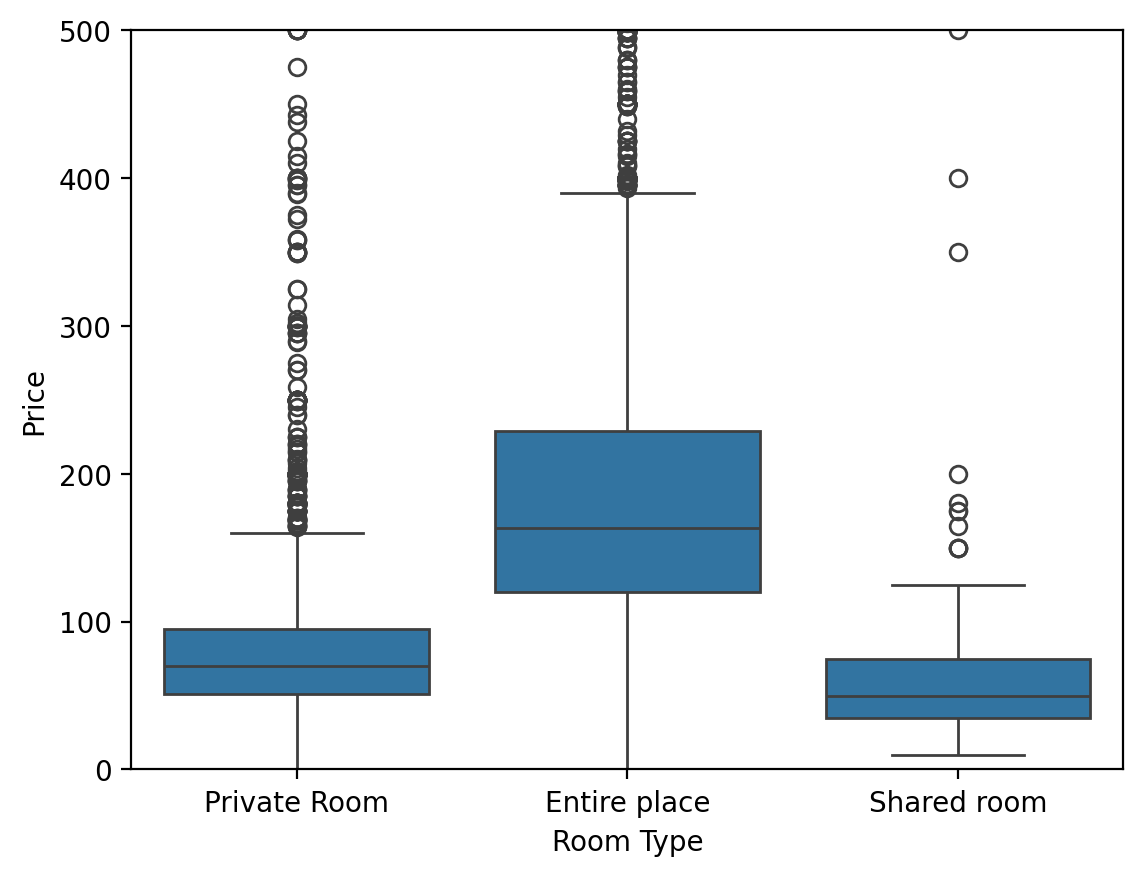

In [390]:
# Visualizing the relationship between price and room_type :
sns.boxplot(x = 'room_type', y = 'price', data = airbnb)
plt.ylim(0, 500)
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

In [391]:
fig = px.box(x = airbnb['room_type'], y = airbnb['price'])
fig.show()

In [392]:
# Getting median price per room_type :
airbnb.groupby('room_type').median(numeric_only = True)

,listing_id,host_id,price,number_of_reviews,reviews_per_month,availability_365,rating,number_of_stays,5_stars,latitude,longitude,is_rated
room_type,,,,,,,,,,,,
Entire place,19339382.5,25577360.0,163.0,5.0,0.36,41.0,4.028458,6.0,0.683422,40.727100,-73.965165,1.0
Private Room,20503660.0,37597301.5,70.0,5.0,0.39,44.0,4.028934,6.0,0.680119,40.717535,-73.947755,1.0
Shared room,26964114.5,67435179.5,50.0,4.0,0.43,102.0,4.001926,4.8,0.677202,40.744250,-73.953660,1.0


In [393]:
# Imputing price based on conditions :
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Entire place'), 'price'] = 163.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Private Room'), 'price'] = 70.0
airbnb.loc[(airbnb['price'].isna()) & (airbnb['room_type'] == 'Shared Room'), 'price'] = 50.0

In [394]:
airbnb[airbnb['price'].isna()]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
508,13974200,"Sunny, Pre-War Brooklyn Share",77317167,Stacey Rae,Shared room,NaN,5,2017-10-01,0.15,0,4.752003,6.0,0.658378,2017-03-28,40.65126,-73.96388,Brooklyn,Flatbush,1
1043,33431709,Shared apartment by the Central Park,251852817,Owen,Shared room,NaN,17,2019-06-30,5.10,72,4.683608,20.4,0.917779,2018-12-25,40.80073,-73.94328,Manhattan,East Harlem,1
2086,36118872,A Cozy Bed Dream in Manhattan,178720348,Mingmei,Shared room,NaN,0,NaT,0.00,34,NaN,0.0,0.000000,2018-03-28,40.81851,-73.95670,Manhattan,Harlem,0
3353,21568943,Shareroom in Midtown Manhattan 1or2 beds Avail...,156246842,Sandra,Shared room,NaN,9,2018-08-01,0.45,0,4.382015,10.8,0.634106,2018-01-26,40.76140,-73.98682,Manhattan,Hell's Kitchen,1
3909,30950573,Brooklyn 3 persons shared room close to subway,17706542,Sergey,Shared room,NaN,0,NaT,0.00,342,NaN,0.0,0.000000,2018-09-25,40.69190,-73.90626,Brooklyn,Bushwick,0
8212,7711899,FEMALE ONLY 'Heaven'PrivateBed/SharedSpace w/Wifi,40509550,Denise,Shared room,NaN,14,2018-11-01,0.30,363,4.226222,16.8,0.680988,2018-04-28,40.84805,-73.94209,Manhattan,Washington Heights,1
9793,6155877,Solo traveler oasis,18248926,Yana,Shared room,NaN,84,2019-06-15,2.26,347,4.086250,100.8,0.601364,2018-12-10,40.82434,-73.94816,Manhattan,Harlem,1


In [395]:
airbnb.isna().sum()

listing_id              0
name                    5
host_id                 0
host_name               2
room_type               0
price                   7
number_of_reviews       0
last_review          2075
reviews_per_month       0
availability_365        0
rating               2075
number_of_stays         0
5_stars                 0
listing_added           0
latitude                0
longitude               0
borough                 0
neighbourhood           0
is_rated                0
dtype: int64

In [396]:
# Doing some sanity checks on date data :
today = dt.date.today()

In [397]:
# Are there reviews in the future ?
airbnb[airbnb['last_review'].dt.date > today]

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated


In [398]:
# Dropping these rows since they are only 4 rows
airbnb = airbnb[~(airbnb['listing_added'].dt.date > today)]

In [399]:
# Are there any listings with listing_added > last_review
inconsistent_dates = airbnb[airbnb['listing_added'].dt.date > airbnb['last_review'].dt.date]
inconsistent_dates

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private Room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,40.71884,-73.98354,Manhattan,Lower East Side,1
50,20783900,Marvelous Manhattan Marble Hill Private Suites,148960265,Randy,Private Room,93.0,7,2018-10-06,0.32,0,4.868036,8.4,0.609263,2020-02-17,40.87618,-73.91266,Manhattan,Marble Hill,1
60,1908852,Oversized Studio By Columbus Circle,684629,Alana,Entire place,189.0,7,2016-05-06,0.13,0,4.841204,8.4,0.725995,2017-09-17,40.77060,-73.98919,Manhattan,Upper West Side,1
124,28659894,Private bedroom in prime Bushwick! Near Trains!!!,216235179,Nina,Private Room,55.0,4,2019-04-12,0.58,358,4.916252,4.8,0.703117,2020-08-23,40.69988,-73.92072,Brooklyn,Bushwick,1
511,33619855,Modern & Spacious in trendy Crown Heights,253354074,Yehudis,Entire place,150.0,6,2019-05-27,2.50,148,3.462432,7.2,0.610929,2020-10-07,40.66387,-73.93840,Brooklyn,Crown Heights,1
521,25317793,Awesome Cozy Room in The Heart of Sunnyside!,136406167,Kara,Private Room,65.0,22,2019-06-11,1.63,131,4.442485,26.4,0.722388,2020-10-22,40.74090,-73.92696,Queens,Sunnyside,1


In [400]:
# Dropping these rows since they are only 2 rows :
airbnb.drop(inconsistent_dates.index, inplace = True)

In [401]:
# Print the header of the DataFrame again :
airbnb.head()

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side,1
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire place,150.0,0,NaT,0.00,65,NaN,0.0,0.000000,2018-08-15,40.70070,-73.99517,Brooklyn,Brooklyn Heights,0
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Manhattan,Upper West Side,1
5,271954,Beautiful brownstone apartment,1423798,Aj,Entire place,150.0,203,2019-06-20,2.22,300,4.478396,243.6,0.743500,2018-12-15,40.73388,-73.99452,Manhattan,Greenwich Village,1


In [463]:
duplicates = airbnb.duplicated(subset = 'listing_id', keep = False)
print(duplicates)

0        False
1        False
2        False
3        False
5        False
         ...  
10014    False
10015    False
10016    False
10017    False
10018    False
Length: 10010, dtype: bool


In [465]:
# Finding duplicates :
airbnb[duplicates].sort_values('listing_id')

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
1145,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,Entire place,199.0,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
6562,253806,Loft Suite @ The Box House Hotel,417504,The Box House Hotel,Entire place,199.0,43,2019-07-02,0.47,60,4.620238,51.6,0.861086,2018-12-27,40.73652,-73.95236,Brooklyn,Greenpoint,1
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,245.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,250.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,73.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,70.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,289.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,280.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,154.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,150.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1


In [473]:
# Removing identical duplicates :
airbnb = airbnb.drop_duplicates()

In [469]:
# Finding non-identical duplicates :
duplicates = airbnb.duplicated(subset = 'listing_id', keep = False)

In [471]:
# Showing all duplicates :
airbnb[duplicates].sort_values('listing_id')

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
5761,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,250.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-05-24,40.71257,-73.96149,Brooklyn,Williamsburg,0
8699,2044392,The heart of Williamsburg 2 bedroom,620218,Sarah,Entire place,245.0,0,NaT,0.00,0,NaN,0.0,0.000000,2018-08-09,40.71257,-73.96149,Brooklyn,Williamsburg,0
2871,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,70.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
4187,4244242,Best Bedroom in Bedstuy/Bushwick. Ensuite bath...,22023014,BrooklynSleeps,Private Room,73.0,110,2019-06-23,1.96,323,4.962314,132.0,0.809882,2018-12-18,40.69496,-73.93949,Brooklyn,Bedford-Stuyvesant,1
77,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,289.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
2255,7319856,450ft Square Studio in Gramercy NY,11773680,Adam,Entire place,280.0,4,2016-05-22,0.09,225,3.903764,4.8,0.756381,2015-11-17,40.73813,-73.98098,Manhattan,Kips Bay,1
555,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,154.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
7933,9078222,"Prospect Park 3 bdrm, Sleeps 8 (#2)",47219962,Babajide,Entire place,150.0,123,2019-07-01,2.74,263,3.466881,147.6,0.738191,2018-12-26,40.66086,-73.96159,Brooklyn,Prospect-Lefferts Gardens,1
1481,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.969729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1
3430,15027024,Newly renovated 1bd on lively & historic St Marks,8344620,Ethan,Entire place,180.0,10,2018-12-31,0.30,0,3.869729,12.0,0.772513,2018-06-27,40.72693,-73.98385,Manhattan,East Village,1


In [475]:
# Getting column names from airbnb :
column_names = airbnb.columns
column_names

Index(['listing_id', 'name', 'host_id', 'host_name', 'room_type', 'price',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'availability_365', 'rating', 'number_of_stays', '5_stars',
       'listing_added', 'latitude', 'longitude', 'borough', 'neighbourhood',
       'is_rated'],
      dtype='object')

In [477]:
# Creating dictionary comprehension with 'first' as value for all columns not being aggregated :
aggregations = {column_name:'first' for column_name in column_names.difference(['listing_id', 'listing_added', 'rating', 'price'])}
aggregations['price'] = 'mean'
aggregations['rating'] = 'mean'
aggregations['listing_added'] = 'max'
aggregations

{'5_stars': 'first',
 'availability_365': 'first',
 'borough': 'first',
 'host_id': 'first',
 'host_name': 'first',
 'is_rated': 'first',
 'last_review': 'first',
 'latitude': 'first',
 'longitude': 'first',
 'name': 'first',
 'neighbourhood': 'first',
 'number_of_reviews': 'first',
 'number_of_stays': 'first',
 'reviews_per_month': 'first',
 'room_type': 'first',
 'price': 'mean',
 'rating': 'mean',
 'listing_added': 'max'}

In [479]:
# Removing non-identical duplicates :
airbnb = airbnb.groupby('listing_id').agg(aggregations).reset_index()

In [481]:
# Making sure no duplication happened :
airbnb[airbnb.duplicated('listing_id', keep = False)]

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added


In [483]:
# Printing header of DataFrame ing
airbnb.head()

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added
0,3831,0.757366,194,Brooklyn,4869,LisaRoxanne,1,2019-07-05,40.68514,-73.95976,Cozy Entire Floor of Brownstone,Clinton Hill,270,324.0,4.64,Entire place,89.0,3.273935,2018-12-30
1,6848,0.789743,46,Brooklyn,15991,Allen & Irina,1,2019-06-29,40.70837,-73.95352,Only 2 stops to Manhattan studio,Williamsburg,148,177.6,1.20,Entire place,140.0,3.495760,2018-12-24
2,7322,0.669873,12,Manhattan,18946,Doti,1,2019-07-01,40.74192,-73.99501,Chelsea Perfect,Chelsea,260,312.0,2.12,Private Room,140.0,4.389051,2018-12-26
3,7726,0.640251,21,Brooklyn,20950,Adam And Charity,1,2019-06-22,40.67592,-73.94694,Hip Historic Brownstone Apartment with Backyard,Crown Heights,53,63.6,4.44,Entire place,99.0,3.305382,2018-12-17
4,12303,0.918593,311,Brooklyn,47618,Yolande,1,2018-09-30,40.69673,-73.97584,1bdr w private bath. in lofty apt,Fort Greene,25,30.0,0.23,Private Room,120.0,4.568745,2018-03-27
